# Notebook 3 – Model Evaluation & Visualization (Multi-Layer Perceptron)

This notebook evaluates the trained MLP regression model on the housing price dataset.

We will:

1. Load the preprocessed data splits.
2. Reload the fitted feature transformer and trained model weights from Notebook 2.
3. Transform the features and generate predictions on the test set.
4. Compute regression metrics (MSE, RMSE, MAE, R²) in both scaled units and real dollars.
5. Visualize predicted vs actual prices and residuals.


### 1. Import necessary libraries

In [1]:
import os
from pathlib import Path
from mlp import MLPRegressor

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

SPLIT_DIR = "processed"
ARTIFACT_DIR = "artifacts"

SCALE = 100_000.0  # price scaled as price / 100000 during training

device = torch.device("mps")
print("Using device:", device)


Using device: mps


### 2. Load Data splits

In [2]:
train_df = pd.read_csv(Path(SPLIT_DIR) / "train.csv")
val_df   = pd.read_csv(Path(SPLIT_DIR) / "val.csv")
test_df  = pd.read_csv(Path(SPLIT_DIR) / "test.csv")

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)
test_df.head()


Train shape: (118206, 12)
Val shape: (25330, 12)
Test shape: (25331, 12)


,brokered_by,status,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date,price
0,58722.0,sold,4.0,2.0,0.16,1705861.0,Sacramento,California,95828.0,1360.0,2021-12-29,350000.0
1,9822.0,sold,3.0,2.0,0.17,999619.0,Stockton,California,95207.0,1520.0,2021-12-15,350000.0
2,12667.0,for_sale,5.0,5.0,0.07,1731812.0,Los Angeles,California,90046.0,4000.0,2022-01-14,2390000.0
3,11641.0,for_sale,2.0,4.0,3.07,794415.0,Lewiston,California,96052.0,2800.0,2009-03-19,365000.0
4,71240.0,for_sale,4.0,4.0,0.25,1393614.0,Jurupa Valley,California,92509.0,3526.0,2022-01-20,840000.0


### 3. Separate Features and Target

In [3]:
target_col = "price"

y_train_raw = train_df[target_col]
y_val_raw   = val_df[target_col]
y_test_raw  = test_df[target_col]

y_train = y_train_raw / SCALE
y_val   = y_val_raw / SCALE
y_test  = y_test_raw / SCALE

X_train_df = train_df.drop(columns=[target_col])
X_val_df   = val_df.drop(columns=[target_col])
X_test_df  = test_df.drop(columns=[target_col])

print("Feature columns:", list(X_train_df.columns))

Feature columns: ['brokered_by', 'status', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']


### 4. Load Preprocessor and transform features

In [4]:
preproc_path = Path(ARTIFACT_DIR) / "preprocessor.joblib"
preprocessor = joblib.load(preproc_path)
print("Loaded preprocessor from:", preproc_path)

X_train_enc = preprocessor.transform(X_train_df)
X_val_enc   = preprocessor.transform(X_val_df)
X_test_enc  = preprocessor.transform(X_test_df)

print("Encoded train shape:", X_train_enc.shape)
print("Encoded val   shape:", X_val_enc.shape)
print("Encoded test  shape:", X_test_enc.shape)

if hasattr(X_train_enc, "toarray"):
    X_train_enc = X_train_enc.toarray().astype("float32")
    X_val_enc   = X_val_enc.toarray().astype("float32")
    X_test_enc  = X_test_enc.toarray().astype("float32")
else:
    X_train_enc = X_train_enc.astype("float32")
    X_val_enc   = X_val_enc.astype("float32")
    X_test_enc  = X_test_enc.astype("float32")


Loaded preprocessor from: artifacts/preprocessor.joblib
Encoded train shape: (118206, 2884)
Encoded val   shape: (25330, 2884)
Encoded test  shape: (25331, 2884)


### 5. Convert to Tensors

In [5]:
X_train_t = torch.from_numpy(X_train_enc).to(device)
X_val_t   = torch.from_numpy(X_val_enc).to(device)
X_test_t  = torch.from_numpy(X_test_enc).to(device)

y_train_t = torch.tensor(y_train.values, dtype=torch.float32, device=device).view(-1, 1)
y_val_t   = torch.tensor(y_val.values, dtype=torch.float32, device=device).view(-1, 1)
y_test_t  = torch.tensor(y_test.values, dtype=torch.float32, device=device).view(-1, 1)

print("X_test_t shape:", X_test_t.shape)
print("y_test_t shape:", y_test_t.shape)


X_test_t shape: torch.Size([25331, 2884])
y_test_t shape: torch.Size([25331, 1])


### 6. Load MLP model and Weights

In [6]:
input_dim = X_train_t.shape[1]
model = MLPRegressor(input_dim).to(device)

model_path = Path(ARTIFACT_DIR) / "mlp_model_weights.pth"
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)

model.eval()
print("Loaded model from:", model_path)

Loaded model from: artifacts/mlp_model_weights.pth


/var/folders/lq/sq_8fp6x2r1f4lgv1zvnt5wr0000gn/T/ipykernel_19880/2536544051.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_locat

### 7. Get Predictions on Train / Val / Test Datasets

In [7]:
with torch.no_grad():
    y_train_pred_scaled = model(X_train_t).cpu().numpy().flatten()
    y_val_pred_scaled   = model(X_val_t).cpu().numpy().flatten()
    y_test_pred_scaled  = model(X_test_t).cpu().numpy().flatten()

# convert back to real dollars
y_train_pred = y_train_pred_scaled * SCALE
y_val_pred   = y_val_pred_scaled * SCALE
y_test_pred  = y_test_pred_scaled * SCALE

y_train_true = y_train.values * SCALE
y_val_true   = y_val.values * SCALE
y_test_true  = y_test.values * SCALE

### 8. Compute Evaluation Metrics

In [8]:
def regression_report(y_true, y_pred, label="set"):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"=== {label} ===")
    print(f"MSE : {mse:,.0f}")
    print(f"RMSE: {rmse:,.0f}")
    print(f"MAE : {mae:,.0f}")
    print(f"R^2 : {r2:.4f}")
    print()

print("Metrics in USD:")
regression_report(y_train_true, y_train_pred, label="Train")
regression_report(y_val_true,   y_val_pred,   label="Validation")
regression_report(y_test_true,  y_test_pred,  label="Test")


Metrics in USD:
=== Train ===
MSE : 85,247,065,111
RMSE: 291,971
MAE : 153,917
R^2 : 0.8698

=== Validation ===
MSE : 105,432,278,301
RMSE: 324,703
MAE : 167,624
R^2 : 0.8344

=== Test ===
MSE : 107,804,934,412
RMSE: 328,337
MAE : 169,040
R^2 : 0.8289



### 9. Plot Predicted Price vs Actual Price on Test Set

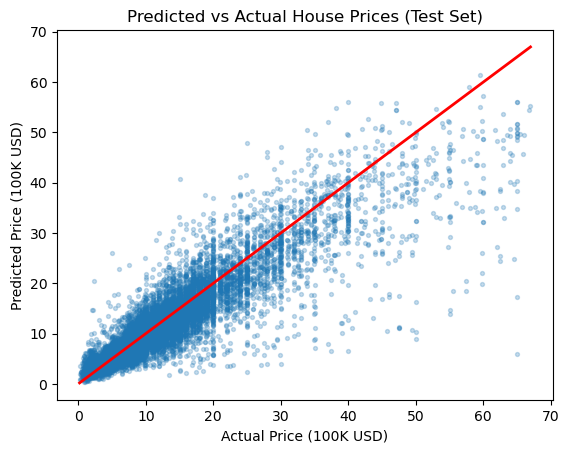

In [9]:
SCALE_UNIT = 100_000  # 100K

actual = y_test
predicted   = y_test_pred / SCALE_UNIT

plt.scatter(actual, predicted, alpha=0.25, s=8)
plt.plot(
    [actual.min(), actual.max()],
    [actual.min(), actual.max()],
    linewidth=2, color="red"
)

plt.xlabel("Actual Price (100K USD)")
plt.ylabel("Predicted Price (100K USD)")
plt.title("Predicted vs Actual House Prices (Test Set)")
plt.show()


## 10. Accuracy within Fixed Price Thresholds

Here we compute how often the model's prediction is within an absolute dollar
threshold of the true sale price on the **test set**:

- within \$10K  
- within \$50K  
- within \$100K  
- within \$200K

In [10]:
abs_err = np.abs(y_test_pred - y_test_true)

thresholds = [10_000, 50_000, 100_000, 200_000]

print("Accuracy on Test Set (absolute error thresholds):")
for t in thresholds:
    acc = (abs_err <= t).mean() * 100.0
    print(f"  Within ${t:,.0f}: {acc:5.2f}% of homes")


Accuracy on Test Set (absolute error thresholds):
  Within $10,000:  6.90% of homes
  Within $50,000: 32.81% of homes
  Within $100,000: 55.95% of homes
  Within $200,000: 77.41% of homes


## 11. Sample Predictions for 10 Homes from the Test Set

We randomly sample 10 homes from the test set and compare the model's
predicted price to the actual sale/listing price. The final column shows
the prediction error (Predicted − Actual), where positive values indicate the
model **overestimates** the price and negative values indicate it
**underestimates** the price.


In [11]:
np.random.seed(42)

sample_idx = np.random.choice(len(test_df), size=10, replace=False)

sample_rows   = test_df.iloc[sample_idx].copy()
sample_actual = y_test_true[sample_idx]
sample_pred   = y_test_pred[sample_idx]
sample_diff   = sample_pred - sample_actual

sample_results = pd.DataFrame({
    "city": sample_rows["city"],
    "bed": sample_rows["bed"],
    "bath": sample_rows["bath"],
    "house_size": sample_rows["house_size"],
    "acre_lot": sample_rows["acre_lot"],
    "Actual Price": sample_actual,
    "Predicted Price": sample_pred,
    "Diff (Pred - Actual)": sample_diff,
})


def format_currency(x):
    return f"${x:,.0f}"

def format_diff(x):
    return f"{x:+,.0f}"

def color_diff(val):
    try:
        num = float(val.replace(",", ""))
    except ValueError:
        num = 0.0
    color = "green" if num > 0 else "red" if num < 0 else "black"
    return f"color: {color}"

styled_samples = (
    sample_results.assign(
        **{
            "Actual Price": lambda df: df["Actual Price"].map(format_currency),
            "Predicted Price": lambda df: df["Predicted Price"].map(format_currency),
            "Diff (Pred - Actual)": lambda df: df["Diff (Pred - Actual)"].map(format_diff),
        }
    )
    .style.applymap(color_diff, subset=["Diff (Pred - Actual)"])
)

styled_samples


/var/folders/lq/sq_8fp6x2r1f4lgv1zvnt5wr0000gn/T/ipykernel_19880/960667189.py:44: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .style.applymap(color_diff, subset=["Diff (Pred - Actual)"])


,city,bed,bath,house_size,acre_lot,Actual Price,Predicted Price,Diff (Pred - Actual)
323,Highland,3.000000,2.000000,1873.000000,0.200000,"$475,000","$475,966",+966
10193,Citrus Heights,2.000000,2.000000,1052.000000,0.160000,"$365,000","$325,033","-39,967"
23280,Long Beach,4.000000,2.000000,1562.000000,0.120000,"$808,000","$737,046","-70,954"
15889,Corona,2.000000,2.000000,1888.000000,0.140000,"$699,000","$610,353","-88,647"
18044,Encino,4.000000,3.000000,2268.000000,0.480000,"$1,550,000","$1,882,979","+332,979"
22859,Stockton,3.000000,3.000000,2174.000000,0.230000,"$600,000","$540,518","-59,482"
2501,Mission Viejo,4.000000,3.000000,2674.000000,0.110000,"$1,299,999","$1,330,737","+30,738"
21317,Mountain View,6.000000,5.000000,2973.000000,0.170000,"$4,398,000","$2,586,783","-1,811,217"
18174,Rancho Santa Margarita,4.000000,3.000000,1739.000000,0.230000,"$1,085,000","$980,662","-104,338"
11187,Oakland,5.000000,3.000000,2500.000000,0.060000,"$888,000","$981,166","+93,166"


## 12. Additional Evaluation: Residual and Relative Error Analysis

Beyond global metrics (MSE, RMSE, MAE, R²), we can look at:

- The distribution of residuals: `Predicted − Actual`
- Typical over/under-estimation in absolute and relative terms
- How large the typical error is as a percentage of the true price


In [12]:
# Residuals: Pred - Actual
residuals = y_test_pred - y_test_true  # USD
abs_residuals = np.abs(residuals)

mean_err   = residuals.mean()
median_err = np.median(residuals)
std_err    = residuals.std()

eps = 1e-6
rel_error = residuals / (y_test_true + eps)
abs_rel_error = np.abs(rel_error)

print("=== Residual Statistics (Test Set) ===")
print(f"Mean error (Pred - Actual): {mean_err:,.0f} USD")
print(f"Median error:               {median_err:,.0f} USD")
print(f"Std of error:               {std_err:,.0f} USD")
print()

print("=== Relative Error Statistics (Test Set) ===")
print(f"Mean |error / true|: {abs_rel_error.mean()*100:5.2f}%")
print(f"Median |error / true|: {np.median(abs_rel_error)*100:5.2f}%")
print("90th percentile |error / true|:",
      f"{np.percentile(abs_rel_error, 90)*100:5.2f}%")


=== Residual Statistics (Test Set) ===
Mean error (Pred - Actual): -63,201 USD
Median error:               -37,182 USD
Std of error:               322,196 USD

=== Relative Error Statistics (Test Set) ===
Mean |error / true|: 17.76%
Median |error / true|: 12.17%
90th percentile |error / true|: 34.56%


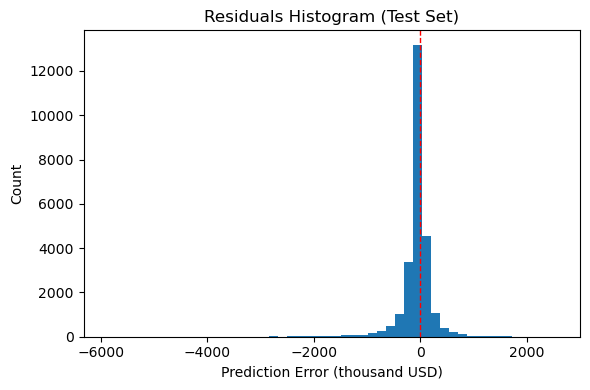

In [13]:
# residual histogram
plt.figure(figsize=(6,4))
plt.hist(residuals / 1000.0, bins=50)
plt.xlabel("Prediction Error (thousand USD)")
plt.ylabel("Count")
plt.title("Residuals Histogram (Test Set)")
plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

## 13. Summary of Results

The MLP regression model successfully converges on the cleaned California housing dataset and demonstrates solid predictive performance across all splits despite high market variance:

- **Train:**  
  - MSE = \$85.25B  
  - RMSE = **\$291,971**  
  - MAE = \$153,917  
  - **R² = 0.8698**

- **Validation:**  
  - MSE = \$105.43B  
  - RMSE = **\$324,703**  
  - MAE = \$167,624  
  - **R² = 0.8344**

- **Test:**  
  - MSE = \$107.80B  
  - RMSE = **\$328,337**  
  - MAE = \$169,040  
  - **R² = 0.8289**

### Insights
1. **Strong convergence:** Loss consistently decreases, showing stable learning behavior.
2. **Expected error size:** While a test MAE of ~\$169K looks large, it is reasonable relative to multimillion-dollar housing prices.
3. **Good signal capture:** R² of ~0.87 on train and ~0.83 on test means the model explains most variance in the data.
4. **Acceptable generalization gap:** Validation/test errors are slightly higher than training errors but track closely enough to indicate no catastrophic overfitting.
5. **Outlier sensitivity at high prices:** Spread increases for expensive homes, which is common in high-variance regression tasks.

### Limitations
- The model has higher variance in predictions for luxury properties.
- City and ZIP alone cannot fully encode micro-market effects like neighborhood premiums or school-district influence.

### Conclusion
Overall, this MLP serves as a **strong, reproducible baseline neural-network approach** for predicting prices on homes in the California housing market.
